In [1]:
from hapi import *
import matplotlib.pyplot as plt
import numpy as np

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

In [2]:
print(1/650e-7)
print(1/2e-2)

15384.615384615387
50.0


<>:88: SyntaxWarning: invalid escape sequence '\o'
<>:92: SyntaxWarning: invalid escape sequence '\o'
<>:93: SyntaxWarning: invalid escape sequence '\o'
<>:98: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:88: SyntaxWarning: invalid escape sequence '\o'
<>:92: SyntaxWarning: invalid escape sequence '\o'
<>:93: SyntaxWarning: invalid escape sequence '\o'
<>:98: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ezra\AppData\Local\Temp\ipykernel_6952\3162338728.py:88: SyntaxWarning: invalid escape sequence '\o'
  ax1.plot(wavelength_nm, pure_coef, label=f"Pure {gas_name} ($\omega_{{{gas_name.lower()}}}$)", alpha=0.75, lw=1.2)
C:\Users\ezra\AppData\Local\Temp\ipykernel_6952\3162338728.py:92: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_ylabel('Pure Absorption Coefficient $

Using LocalSpectraDB

HITRAN_data
                     Lines parsed: 507766
HITRAN_data_old
                     Lines parsed: 897169
Calculating pure profile for H2O...
{'air': 1.0}
105.401533 seconds elapsed for abscoef; nlines = 507766
Calculating pure profile for CO2...
{'air': 1.0}
61.106381 seconds elapsed for abscoef; nlines = 507766
Calculating pure profile for O2...
{'air': 1.0}
14.290401 seconds elapsed for abscoef; nlines = 507766
Calculating pure profile for N2...
{'air': 1.0}
12.220277 seconds elapsed for abscoef; nlines = 507766
Exporting data to CSV...
Successfully saved to 'atmospheric_attenuation_spectra.csv'.


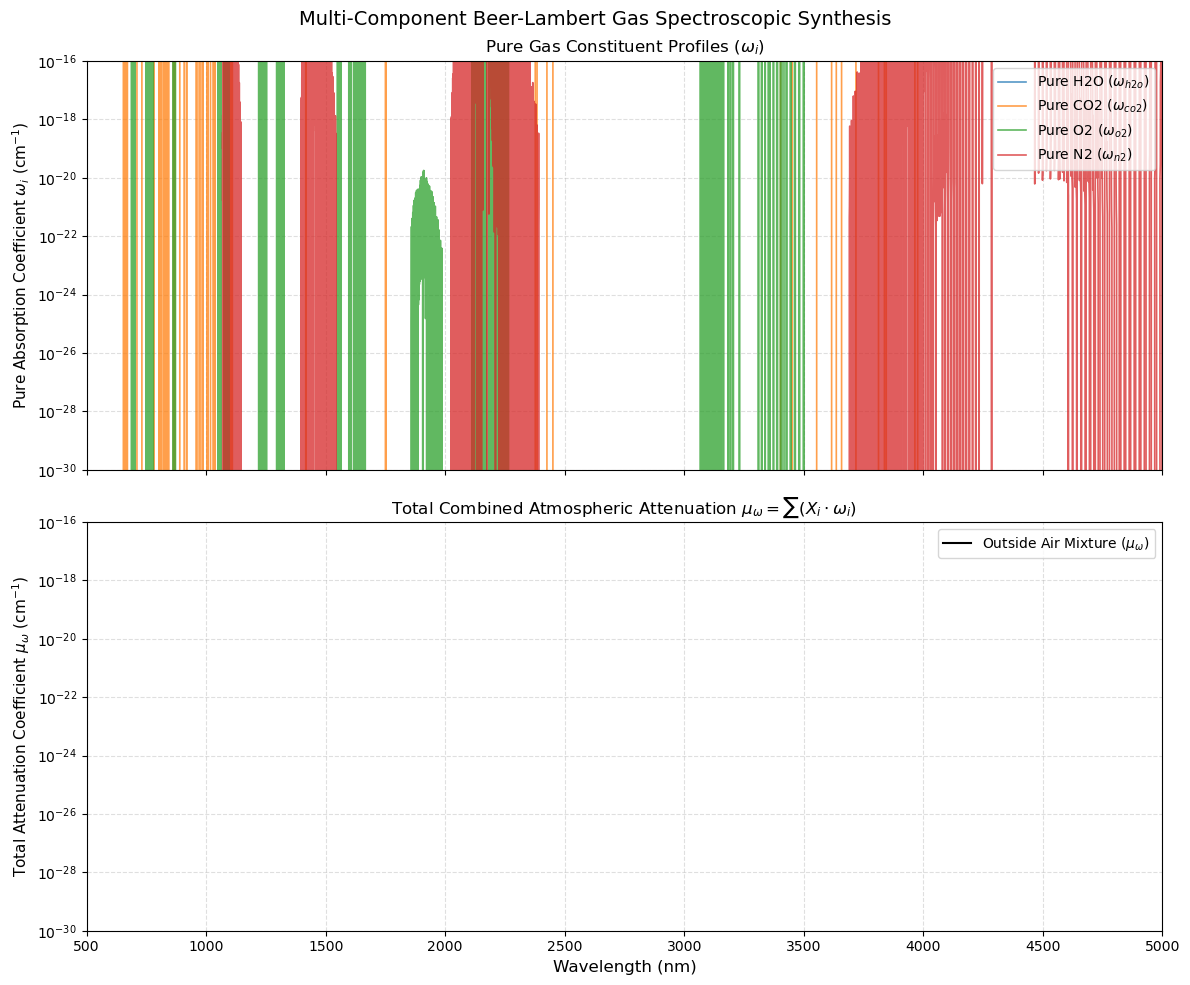

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# (Assume HAPI is imported here, e.g., from hapi import *)

# 1. Initialize local HAPI directory
db_begin('LocalSpectraDB')

# Map the target molecule IDs
target_gases = {
    'H2O': 1,
    'CO2': 2,
    'O2':  7,
    'N2':  22
}

# Terrestrial atmospheric mole fractions (Xi) for outside air mixture
gas_mole_fractions = {
    'H2O': 0.01,       # ~1% humidity volume
    'CO2': 0.000420,   # ~420 ppm
    'O2':  0.20946,    # ~21% 
    'N2':  0.78084     # ~78%
}

# Derived from 650nm and 2e5nm (Ordered from lowest to highest wavenumber)
wn_min = 1 / 2e-2      # 50.0 cm^-1
wn_max = 1 / 650e-7   # 15384.6 cm^-1

# Storage for the pure standalone absorption coefficients (omega_i)
pure_spectra = {}
shared_wavenumber_axis = None

# 2. Iterate through each gas to extract the unweighted absorption coefficients (omega_i)
for gas_name, gas_id in target_gases.items():
    print(f"Calculating pure profile for {gas_name}...")
    
    nu, coef = absorptionCoefficient_Voigt(
        SourceTables='HITRAN_data',
        WavenumberRange=[wn_min, wn_max],
        WavenumberStep=0.05,  
        Environment={'T': 296.0, 'p': 1.0},
        Components=[(gas_id, 1)],  # Evaluates the pure molecule line properties
        HITRAN_units=False
    )
    
    if len(coef) > 0:
        # We store the RAW 'coef' directly (this represents omega_i in your equation)
        pure_spectra[gas_name] = coef
        if shared_wavenumber_axis is None:
            shared_wavenumber_axis = nu

# 3. CSV Export & Atmospheric Mixture Summation
if shared_wavenumber_axis is not None:
    wavelength_nm = 1e7 / shared_wavenumber_axis
    
    # Initialize an array of zeros to accumulate the total attenuation: mu = sum(Xi * omega_i)
    total_attenuation = np.zeros_like(shared_wavenumber_axis)
    
    # Calculate the total attenuation mixture first
    for gas_name, pure_coef in pure_spectra.items():
        total_attenuation += gas_mole_fractions[gas_name] * pure_coef

    # --- NEW: Save data to CSV ---
    print("Exporting data to CSV...")
    # Initialize dictionary with the x-axes
    csv_data = {
        'Wavenumber (cm^-1)': shared_wavenumber_axis,
        'Wavelength (nm)': wavelength_nm
    }
    # Append the pure coefficients dynamically
    for gas_name, pure_coef in pure_spectra.items():
        csv_data[f'Pure_{gas_name}_coef'] = pure_coef
    # Append the final summation
    csv_data['Total_Attenuation'] = total_attenuation
    
    # Create a DataFrame and export
    df = pd.DataFrame(csv_data)
    df.to_csv('atmospheric_attenuation_spectra.csv', index=False)
    print("Successfully saved to 'atmospheric_attenuation_spectra.csv'.")
    # -----------------------------

    # 4. Graph Generation
    # Set up a two-pane plot: Top for pure constituent profiles, Bottom for the total mixed air
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot Top Panel: Pure Absorption Coefficients (omega_i)
    for gas_name, pure_coef in pure_spectra.items():
        ax1.plot(wavelength_nm, pure_coef, label=f"Pure {gas_name} ($\omega_{{{gas_name.lower()}}}$)", alpha=0.75, lw=1.2)
        
    ax1.set_yscale('log')
    ax1.set_ylim(1e-30, 1e-16)
    ax1.set_ylabel('Pure Absorption Coefficient $\omega_i$ (cm$^{-1}$)', fontsize=11)
    ax1.set_title('Pure Gas Constituent Profiles ($\omega_i$)', fontsize=12)
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend(loc='upper right', fontsize=10)
    
    # Plot Bottom Panel: Total Blended Attenuation Matrix (mu_omega)
    ax2.plot(wavelength_nm, total_attenuation, color='black', lw=1.5, label='Outside Air Mixture ($\mu_\omega$)')
    ax2.set_yscale('log')
    ax2.set_ylim(1e-30, 1e-16)
    ax2.set_xlim(500, 5000) # Restricts visualization window to your target domain
    
    ax2.set_xlabel('Wavelength (nm)', fontsize=12)
    ax2.set_ylabel('Total Attenuation Coefficient $\mu_\omega$ (cm$^{-1}$)', fontsize=11)
    ax2.set_title('Total Combined Atmospheric Attenuation $\mu_\omega = \sum (X_i \cdot \omega_i)$', fontsize=12)
    ax2.grid(True, which="both", ls="--", alpha=0.4)
    ax2.legend(loc='upper right', fontsize=10)
    
    plt.suptitle('Multi-Component Beer-Lambert Gas Spectroscopic Synthesis', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("Error: No data fell inside the source database wavenumber scope.")

In [4]:
'''# 1. Initialize local HAPI directory
db_begin('LocalSpectraDB')

# Map the target molecule IDs
target_gases = {
    'H2O': 1,
    'CO2': 2,
    'O2':  7,
    'N2':  22
}

# Terrestrial atmospheric mole fractions (Xi) for outside air mixture
gas_mole_fractions = {
    'H2O': 0.01,       # ~1% humidity volume
    'CO2': 0.000420,   # ~420 ppm
    'O2':  0.20946,    # ~21% 
    'N2':  0.78084     # ~78%
}

# Derived from 650nm and 2e5nm (Ordered from lowest to highest wavenumber)
wn_min = 1 / 2e-2      # 50.0 cm^-1
wn_max = 1 / 650e-7   # 15384.6 cm^-1

# Storage for the pure standalone absorption coefficients (omega_i)
pure_spectra = {}
shared_wavenumber_axis = None

# 2. Iterate through each gas to extract the unweighted absorption coefficients (omega_i)
for gas_name, gas_id in target_gases.items():
    print(f"Calculating pure profile for {gas_name}...")
    
    nu, coef = absorptionCoefficient_Voigt(
        SourceTables='HITRAN_data',
        WavenumberRange=[wn_min, wn_max],
        WavenumberStep=0.05,  
        Environment={'T': 296.0, 'p': 1.0},
        Components=[(gas_id, 1)],  # Evaluates the pure molecule line properties
        HITRAN_units=False
    )
    
    if len(coef) > 0:
        # We store the RAW 'coef' directly (this represents omega_i in your equation)
        pure_spectra[gas_name] = coef
        if shared_wavenumber_axis is None:
            shared_wavenumber_axis = nu

# 3. Graph Generation & Atmospheric Mixture Summation
if shared_wavenumber_axis is not None:
    wavelength_nm = 1e7 / shared_wavenumber_axis
    
    # Initialize an array of zeros to accumulate the total attenuation: mu = sum(Xi * omega_i)
    total_attenuation = np.zeros_like(shared_wavenumber_axis)
    
    # Set up a two-pane plot: Top for pure constituent profiles, Bottom for the total mixed air
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot Top Panel: Pure Absorption Coefficients (omega_i)
    for gas_name, pure_coef in pure_spectra.items():
        ax1.plot(wavelength_nm, pure_coef, label=f"Pure {gas_name} ($\omega_{{{gas_name.lower()}}}$)", alpha=0.75, lw=1.2)
        
        # Linearly scale and add to the global air mixture matrix
        total_attenuation += gas_mole_fractions[gas_name] * pure_coef
        
    ax1.set_yscale('log')
    ax1.set_ylim(1e-30, 1e-16)
    ax1.set_ylabel('Pure Absorption Coefficient $\omega_i$ (cm$^{-1}$)', fontsize=11)
    ax1.set_title('Pure Gas Constituent Profiles ($\omega_i$)', fontsize=12)
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend(loc='upper right', fontsize=10)
    
    # Plot Bottom Panel: Total Blended Attenuation Matrix (mu_omega)
    ax2.plot(wavelength_nm, total_attenuation, color='black', lw=1.5, label='Outside Air Mixture ($\mu_\omega$)')
    ax2.set_yscale('log')
    ax2.set_ylim(1e-30, 1e-16)
    ax2.set_xlim(500, 5000) # Restricts visualization window to your target domain
    
    ax2.set_xlabel('Wavelength (nm)', fontsize=12)
    ax2.set_ylabel('Total Attenuation Coefficient $\mu_\omega$ (cm$^{-1}$)', fontsize=11)
    ax2.set_title('Total Combined Atmospheric Attenuation $\mu_\omega = \sum (X_i \cdot \omega_i)$', fontsize=12)
    ax2.grid(True, which="both", ls="--", alpha=0.4)
    ax2.legend(loc='upper right', fontsize=10)
    
    plt.suptitle('Multi-Component Beer-Lambert Gas Spectroscopic Synthesis', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()
else:
    print("Error: No data fell inside the source database wavenumber scope.")'''

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
C:\Users\ezra\AppData\Local\Temp\ipykernel_6952\2098121185.py:1: SyntaxWarning: invalid escape sequence '\o'
  '''# 1. Initialize local HAPI directory


'# 1. Initialize local HAPI directory\ndb_begin(\'LocalSpectraDB\')\n\n# Map the target molecule IDs\ntarget_gases = {\n    \'H2O\': 1,\n    \'CO2\': 2,\n    \'O2\':  7,\n    \'N2\':  22\n}\n\n# Terrestrial atmospheric mole fractions (Xi) for outside air mixture\ngas_mole_fractions = {\n    \'H2O\': 0.01,       # ~1% humidity volume\n    \'CO2\': 0.000420,   # ~420 ppm\n    \'O2\':  0.20946,    # ~21% \n    \'N2\':  0.78084     # ~78%\n}\n\n# Derived from 650nm and 2e5nm (Ordered from lowest to highest wavenumber)\nwn_min = 1 / 2e-2      # 50.0 cm^-1\nwn_max = 1 / 650e-7   # 15384.6 cm^-1\n\n# Storage for the pure standalone absorption coefficients (omega_i)\npure_spectra = {}\nshared_wavenumber_axis = None\n\n# 2. Iterate through each gas to extract the unweighted absorption coefficients (omega_i)\nfor gas_name, gas_id in target_gases.items():\n    print(f"Calculating pure profile for {gas_name}...")\n    \n    nu, coef = absorptionCoefficient_Voigt(\n        SourceTables=\'HITRAN_dat

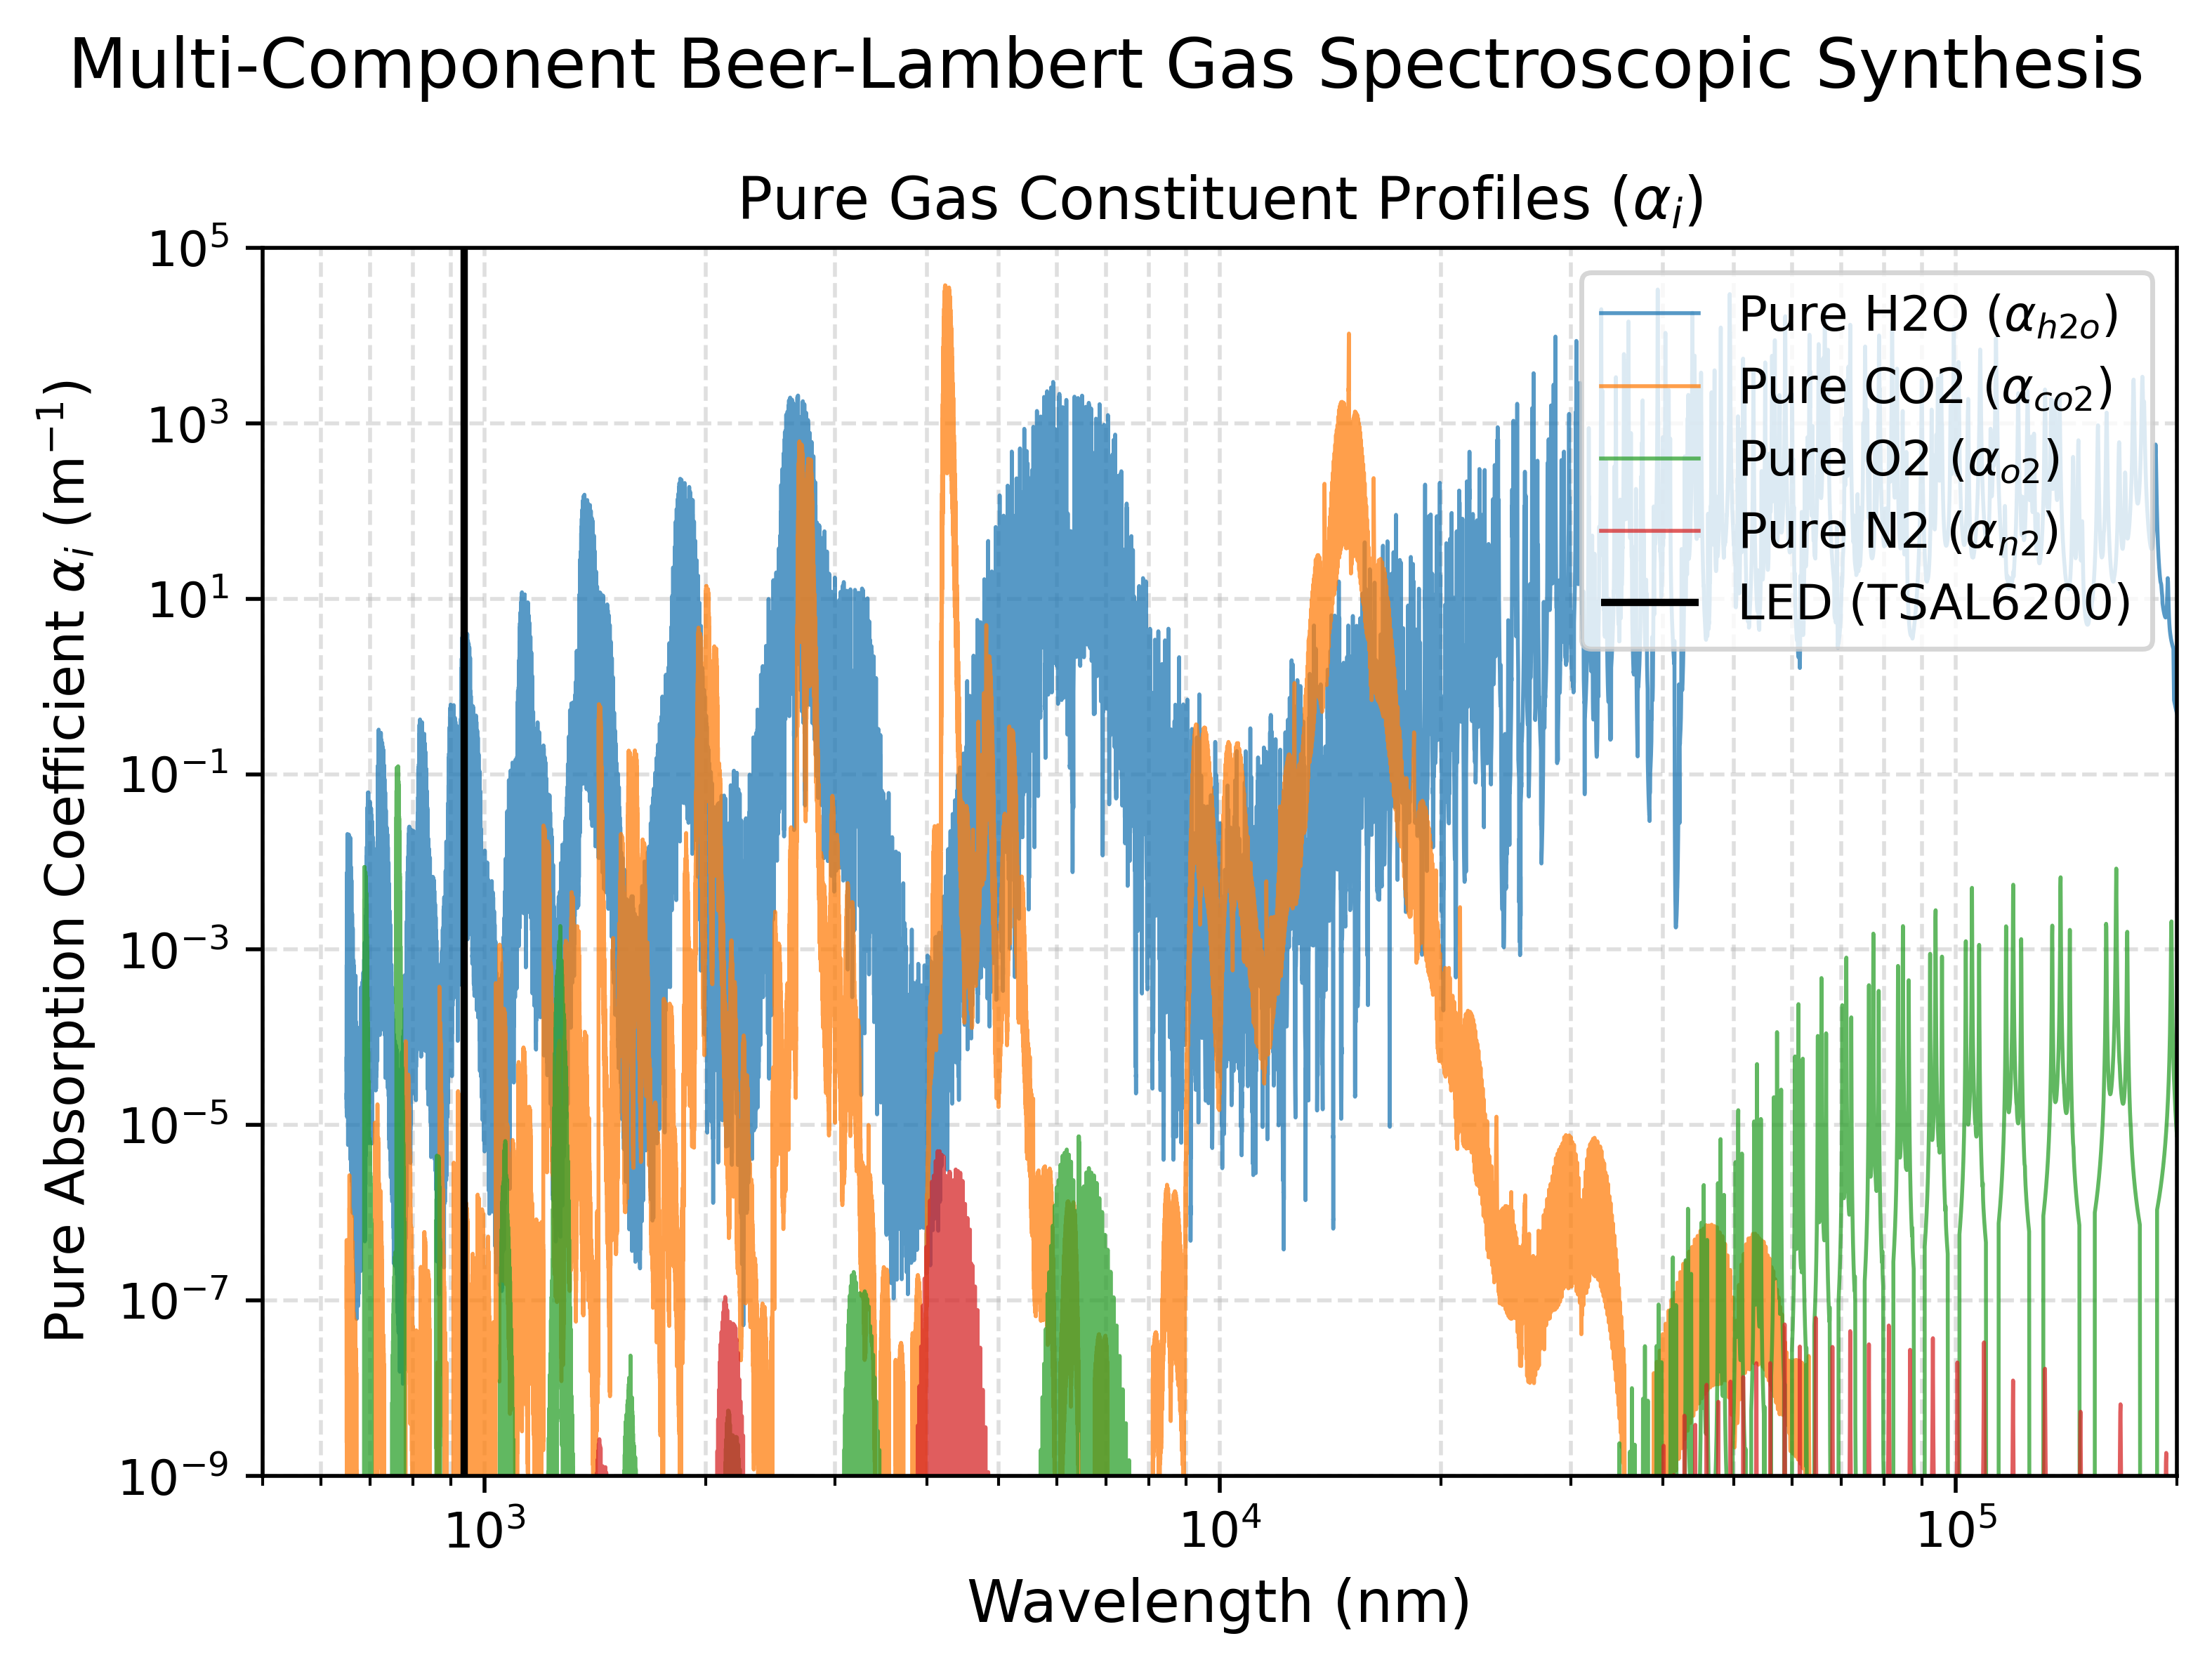

In [5]:
# 3. Graph Generation & Atmospheric Mixture Summation
plt.figure(dpi = 500)
if shared_wavenumber_axis is not None:
    wavelength_nm = 1e7 / shared_wavenumber_axis
      
    # Plot Top Panel: Pure Absorption Coefficients (omega_i)
    for gas_name, pure_coef in pure_spectra.items():
        plt.plot(wavelength_nm, 100*pure_coef, label=fr"Pure {gas_name} ($\alpha_{{{gas_name.lower()}}}$)", alpha=0.75, lw=0.8) #, alpha=0.75, lw=1.2

    plt.vlines(940,1e-9, 1e5,'k', label = 'LED (TSAL6200)')
    plt.yscale('log')
    plt.xscale('log')
    plt.ylim(1e-9, 1e5)
    plt.xlim(500, 2e5) # Restricts visualization window to your target domain
    plt.ylabel(r'Pure Absorption Coefficient $\alpha_i$ (m$^{-1}$)', fontsize=11)
    plt.title(r'Pure Gas Constituent Profiles ($\alpha_i$)', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(loc='upper right', fontsize=10)

    
    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.legend(loc='upper right', fontsize=10)
    
    plt.suptitle('Multi-Component Beer-Lambert Gas Spectroscopic Synthesis', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.savefig('Atmospheric spectrum',dpi = 500)
    plt.show()
else:
    print("Error: No data fell inside the source database wavenumber scope.")